In [108]:
from copy import deepcopy
from tqdm import tqdm
from helpers import get_TBlogger, Settings
from models import DataModel

import glob
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn import metrics
import numpy as np

from utils import load_models

import logging

logger = logging.getLogger(__name__)

settings = Settings()

TBlogger = get_TBlogger(settings.LOGGING_DIR, settings.EXPERIMENT_NAME)


In [109]:
dataModel = DataModel(settings.DATASET_DIR, 
                    settings.CSV_FILE, 
                    settings.FUNDUS_DIR, 
                    settings.TRAIN_SIZE, 
                    settings.INCLUDE_TEST)

In [110]:




trasnformations =A.Compose([
    A.RandomResizedCrop((224, 224), scale=(0.9, 1.0)),
    #A.HorizontalFlip(p=0.5),
    #A.Rotate(limit=10, p=0.5),
    #A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.7),
    #A.ColorJitter(
    #     brightness=0.1,
    #     contrast=0.1,
    #     saturation=0.05,
    #     hue=0.01,
    #     p=0.5
    # ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

train_loader, val_loader, test_loader = dataModel.get_loaders(settings.BATCH_SIZE, trasnformations)



if settings.USE_ALL_EXPERIMENTS_TO_PREDICT:
    experiments = glob.glob("../logs/*")
else:
    experiments = [f"../logs/{settings.PREDICT_EXPERIMENT_NAME}"]

for PREDICT_EXPERIMENT_NAME in experiments:
    print("#"*40, "Experiment Name:", PREDICT_EXPERIMENT_NAME.split("/")[-1], "#"*40)

    model_lst, passed_models = load_models(modelList=["resnet152"], pretrained=True, EXPERIMENT_NAME=PREDICT_EXPERIMENT_NAME)
    
    for model_name, model in model_lst:
        if model_name not in passed_models:
            with torch.inference_mode():
                model.to("cuda")
                model.eval()
                logits_list= []
                label_list = []
                prob_list = []
                for i, l in val_loader: 
                    l= l.long()
                    logits= model.model(i.to("cuda"))
                    logits_list = np.concatenate((logits_list, logits.argmax(axis=1).detach().cpu().numpy()), axis=None)
                    
                    logits = torch.sigmoid(logits)[:, 1]                  
                    label_list = np.concatenate((label_list, l), axis=None)
                    prob_list = np.concatenate((prob_list, logits.detach().cpu().numpy()), axis=None)
                
                fpr, tpr, thresholds = metrics.roc_curve(label_list, prob_list)

                # print(f"{"#"*20} Model Name: {model_name} {"#"*20}\nTrue predictions: {TP},\nTotal predictions: {TOTP},\nAccuracy: {(TP/TOTP)}%")
                print()
                print()






######################################## Experiment Name: nighnth_try_pretrained ########################################




In [111]:
thres_val = round(thresholds[np.argmax(tpr - fpr)], 3)
thres_val

np.float64(0.461)

In [112]:
thres_val = round(thresholds[np.argmax(tpr - fpr)], 3)
prob_list[np.where(prob_list >= thres_val)] = 1
prob_list[np.where(prob_list != 1)] = 0

In [113]:
tn, fp, fn, tp = metrics.confusion_matrix(label_list, prob_list).ravel()
print(f'AUROC on the validation set is {round(metrics.auc(fpr, tpr), 3)}')
print(f'Threshold determined by Youden index is {thres_val}')
print(f'Accuracy on the validation set is {round((tp + tn) / (tp + tn + fp + fn), 3)}')
print(f'Sensitivity on the validation set is {round(tp / (tp + fn), 3)}')
print(f'Specificity on the validation set is {round(tn / (tn + fp), 3)}')

AUROC on the validation set is 0.986
Threshold determined by Youden index is 0.461
Accuracy on the validation set is 0.949
Sensitivity on the validation set is 0.936
Specificity on the validation set is 0.958


In [114]:
prob_list = []
label_list = []
with torch.no_grad():
    for data in tqdm(test_loader):
        images, labels = data[0].float().to("cuda"), data[1].cpu().numpy()
        outputs = model(images)
        label_list = np.concatenate((label_list, labels), axis=None)
        prob_list = np.concatenate((prob_list, torch.sigmoid(outputs)[:, 1].detach().cpu().numpy()), axis=None)

100%|██████████| 116/116 [01:34<00:00,  1.23it/s]


In [115]:
fpr, tpr, thresholds = metrics.roc_curve(label_list, prob_list)
precision, recall, thresholds = metrics.precision_recall_curve(label_list, prob_list)
auc_std, prc_std, acc_std, sen_std, spe_std, ppv_std, npv_std = \
    bootstrap_cls(prob_list=prob_list, label_list=label_list, threshold=thres_val, times=100)

prob_list[np.where(prob_list >= thres_val)] = 1
prob_list[np.where(prob_list != 1)] = 0
tn, fp, fn, tp = metrics.confusion_matrix(label_list, prob_list).ravel()

print(f'AUROC on the test set is {round(metrics.auc(fpr, tpr), 3)}')
print(f'AUPRC on the test set is {round(metrics.auc(recall, precision), 3)}')
print(f'Threshold determined by Youden index is {thres_val}')
print(f'Accuracy on the test set is {round((tp + tn) / (tp + tn + fp + fn), 3)}')
print(f'Sensitivity on the test set is {round(tp / (tp + fn), 3)}')
print(f'Specificity on the test set is {round(tn / (tn + fp), 3)}')
print(f'PPV on the test set is {round(tp / (tp + fp), 3)}')
print(f'NPV on the test set is {round(tn / (tn + fn), 3)}')

AUROC on the test set is 0.983
AUPRC on the test set is 0.976
Threshold determined by Youden index is 0.461
Accuracy on the test set is 0.938
Sensitivity on the test set is 0.923
Specificity on the test set is 0.947
PPV on the test set is 0.917
NPV on the test set is 0.951


In [116]:
results_df= []
results_df.append([f"DeiT-Tiny", f"{id}", f"{thres_val}",
                       f"{format(metrics.auc(fpr, tpr), '.3f')} ({auc_std})",
                       f"{format(metrics.auc(recall, precision), '.3f')} ({prc_std})",
                       f"{format((tp + tn) / (tp + tn + fp + fn), '.3f')} ({acc_std})",
                       f"{format(tp / (tp + fn), '.3f')} ({sen_std})",
                       f"{format(tn / (tn + fp), '.3f')} ({spe_std})",
                       f"{format(tp / (tp + fp), '.3f')} ({ppv_std})",
                       f"{format(tn / (tn + fn), '.3f')} ({npv_std})",
                       ])

In [105]:
import pandas as pd 

In [106]:
results_df = pd.DataFrame(results_df)
results_df.columns = ['Model', 'Data Split', 'Threshold', 'AUROC', 'AUPRC', 'Accuracy', 'Sensitivity', 'Specificity',
                      'PPV', 'NPV']
# results_df.to_csv("results_deit_tiny_cls.csv", index=False, encoding="cp1252")

In [107]:
results_df

,Model,Data Split,Threshold,AUROC,AUPRC,Accuracy,Sensitivity,Specificity,PPV,NPV
0,DeiT-Tiny,<built-in function id>,0.444,0.987 (0.002184551566301814),0.981 (0.002892627751206244),0.949 (0.004642543829630602),0.938 (0.009039487332412608),0.956 (0.005055365943367392),0.931 (0.00800353374026536),0.961 (0.005986319711326544)


In [121]:
f = glob.glob("*.csv")
f

['test_results_cls.csv', 'val_results_cls.csv']

In [122]:
pd.read_csv(f[0])

,Model,EXPERIMENT_NAME,Threshold,AUROC,AUPRC,Accuracy,Sensitivity,Specificity,PPV,NPV
0,resnet50,nighnth_try_pretrained,0.377,0.986 (0.0029792215927704033),0.983 (0.003639329938997158),0.949 (0.005648563586596813),0.958 (0.007895964207707966),0.943 (0.00762106957182204),0.913 (0.010951418629067414),0.973 (0.005107600768402823)
1,resnet101,nighnth_try_pretrained,0.524,0.983 (0.0026943618181968646),0.978 (0.003465997351793578),0.949 (0.004996975559032951),0.927 (0.009921552779355034),0.962 (0.005976382554623196),0.939 (0.009030436256139123),0.954 (0.006449651080105148)
2,resnet152,nighnth_try_pretrained,0.446,0.985 (0.002122837621670374),0.979 (0.0029363873438254186),0.939 (0.005608845525880869),0.930 (0.009019047790853817),0.945 (0.006603720760394039),0.915 (0.009533360595621954),0.955 (0.00619810274583416)
3,efficientnet_b4,nighnth_try_pretrained,0.396,0.860 (0.00862992194551493),0.813 (0.014717813198735198),0.753 (0.009229218272352737),0.846 (0.01234370837877515),0.694 (0.01306678208139177),0.636 (0.014875416479592118),0.877 (0.010498166540215273)


In [123]:
pd.read_csv(f[1])


,Model,EXPERIMENT_NAME,Threshold,AUROC,AUPRC,Accuracy,Sensitivity,Specificity,PPV,NPV
0,resnet50,nighnth_try_pretrained,0.377,0.992 (0.003430526352298171),0.989 (0.007185618441635138),0.971 (0.0033334266463537574),0.971 (0.005722356179056381),0.971 (0.004448862617645217),0.955 (0.006641552526804766),0.981 (0.0035954402557521413)
1,resnet101,nighnth_try_pretrained,0.524,0.989 (0.005457040600772817),0.985 (0.010280080418616253),0.957 (0.0049880687492596465),0.938 (0.009238019948505089),0.968 (0.00533253374595328),0.949 (0.008592353368596095),0.961 (0.005896029992849626)
2,resnet152,nighnth_try_pretrained,0.446,0.992 (0.00473141662076508),0.989 (0.009530126512224004),0.964 (0.004572572565753752),0.958 (0.007368709306185269),0.968 (0.005633133195985466),0.950 (0.008599492055043992),0.973 (0.004779397890843842)
3,efficientnet_b4,nighnth_try_pretrained,0.396,0.858 (0.01023932864490733),0.822 (0.016051331625932547),0.796 (0.009521995187746444),0.733 (0.018601144141224626),0.837 (0.01246321375263159),0.739 (0.016947596461353936),0.832 (0.011116210084032943)


# Explaination

In [124]:
from utils import load_models

In [164]:
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import matplotlib.pyplot as plt

In [140]:
trasnformations =A.Compose([
    A.RandomResizedCrop((224, 224), scale=(0.9, 1.0)),
    #A.HorizontalFlip(p=0.5),
    #A.Rotate(limit=10, p=0.5),
    #A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.7),
    #A.ColorJitter(
    #     brightness=0.1,
    #     contrast=0.1,
    #     saturation=0.05,
    #     hue=0.01,
    #     p=0.5
    # ),
    # A.Normalize(
    #     mean=(0.485, 0.456, 0.406),
    #     std=(0.229, 0.224, 0.225)
    # ),
    ToTensorV2()
])

train_loader, val_loader, test_loader = dataModel.get_loaders(settings.BATCH_SIZE, trasnformations)


In [125]:
model_lst, passed_models = load_models(modelList=["resnet152"], pretrained=True, EXPERIMENT_NAME= f"../logs/{settings.PREDICT_EXPERIMENT_NAME}")

In [141]:
i, l = next(iter(test_loader))

In [142]:
i[0].shape

torch.Size([3, 224, 224])

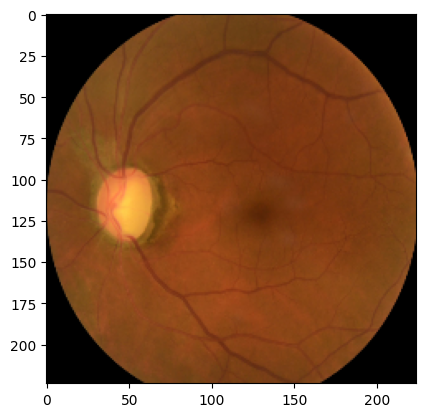

In [146]:
plt.imshow(i[0].permute(1,2,0))

In [192]:
for model_name, model in model_lst:
    model.eval()
    cam_extractor = GradCAM(model, target_layer='model.layer4')
    
    out = model(i[1].to('cuda').float().unsqueeze(0))
    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

In [193]:
activation_map

[tensor([[[0.0041, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0380, 0.0104, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0800, 0.2019, 0.4252, 0.0850, 0.0000],
          [0.0000, 0.0889, 0.1168, 0.2819, 0.2927, 0.2551, 0.8148],
          [0.0000, 0.3518, 0.0923, 0.2480, 0.4168, 0.5368, 0.4858],
          [0.0000, 0.3416, 0.0519, 0.1559, 0.3443, 0.6196, 1.0000],
          [0.0000, 0.0000, 0.0952, 0.1939, 0.1917, 0.5826, 0.4877]]],
        device='cuda:0')]

In [16]:
from PIL import Image

In [188]:
img = i[1]
imgP = Image.fromarray(img.permute(1,2,0).numpy())

In [189]:
cam = Image.fromarray(activation_map[0].squeeze(0).cpu().numpy())

In [190]:
cam

<PIL.Image.Image image mode=F size=7x7>

In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms, models
from PIL import Image
from torchcam.methods import GradCAM, GradCAMpp, ScoreCAM
from torchcam.utils import overlay_mask
from utils import load_models
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import cv2
import matplotlib.cm as cm
from helpers import Settings

In [2]:
trasnformations =A.Compose([
    A.RandomResizedCrop((224, 224), scale=(0.9, 1.0)),
    A.pytorch.ToTensorV2()
])
settings = Settings()

In [3]:
from models import DataModel
dataModel = DataModel(settings.DATASET_DIR, 
                    settings.CSV_FILE, 
                    settings.FUNDUS_DIR, 
                    settings.TRAIN_SIZE, 
                    settings.INCLUDE_TEST)
train_loader, val_loader, test_loader = dataModel.get_loaders(settings.BATCH_SIZE, trasnformations)

In [4]:
PREDICT_EXPERIMENT_NAME=f"../logs/{settings.PREDICT_EXPERIMENT_NAME}"

# model_lst, passed_models = load_models(modelList=["resnet152"], pretrained=True, EXPERIMENT_NAME=PREDICT_EXPERIMENT_NAME)
# model_name, model = list(model_lst)[0]



In [5]:
ter = iter(test_loader)

In [6]:
i, l = next(ter)

In [61]:
[name for name, val in model.model.named_parameters()]

['conv1.weight',
 'bn1.weight',
 'bn1.bias',
 'layer1.0.conv1.weight',
 'layer1.0.bn1.weight',
 'layer1.0.bn1.bias',
 'layer1.0.conv2.weight',
 'layer1.0.bn2.weight',
 'layer1.0.bn2.bias',
 'layer1.0.conv3.weight',
 'layer1.0.bn3.weight',
 'layer1.0.bn3.bias',
 'layer1.0.downsample.0.weight',
 'layer1.0.downsample.1.weight',
 'layer1.0.downsample.1.bias',
 'layer1.1.conv1.weight',
 'layer1.1.bn1.weight',
 'layer1.1.bn1.bias',
 'layer1.1.conv2.weight',
 'layer1.1.bn2.weight',
 'layer1.1.bn2.bias',
 'layer1.1.conv3.weight',
 'layer1.1.bn3.weight',
 'layer1.1.bn3.bias',
 'layer1.2.conv1.weight',
 'layer1.2.bn1.weight',
 'layer1.2.bn1.bias',
 'layer1.2.conv2.weight',
 'layer1.2.bn2.weight',
 'layer1.2.bn2.bias',
 'layer1.2.conv3.weight',
 'layer1.2.bn3.weight',
 'layer1.2.bn3.bias',
 'layer2.0.conv1.weight',
 'layer2.0.bn1.weight',
 'layer2.0.bn1.bias',
 'layer2.0.conv2.weight',
 'layer2.0.bn2.weight',
 'layer2.0.bn2.bias',
 'layer2.0.conv3.weight',
 'layer2.0.bn3.weight',
 'layer2.0.bn3.b

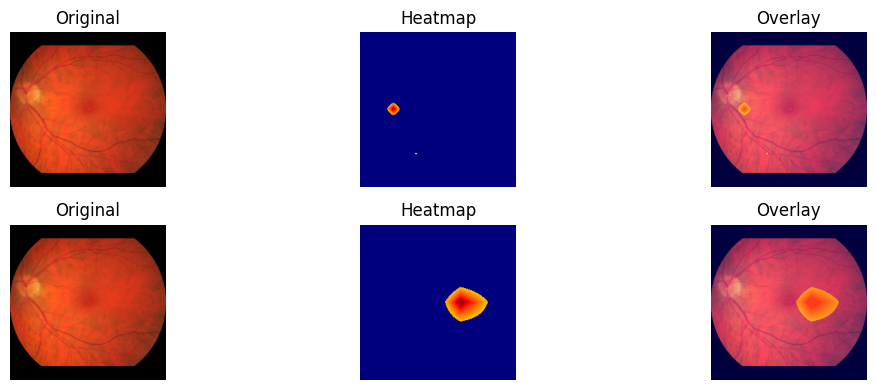

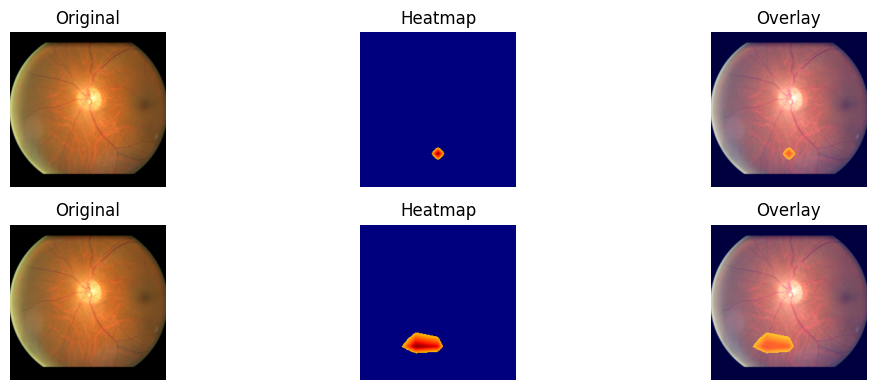

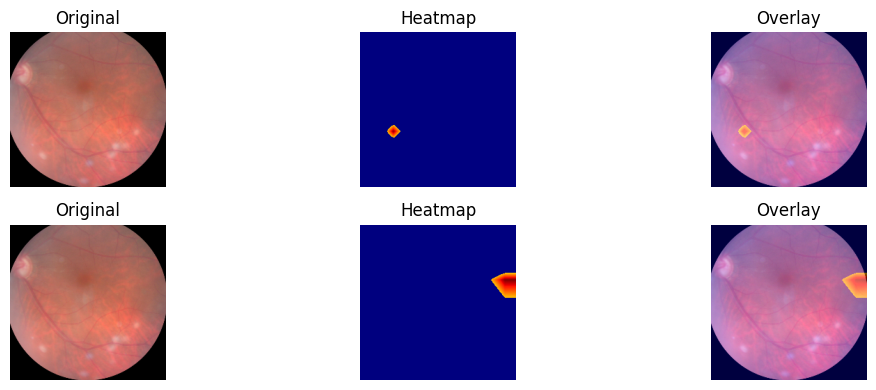

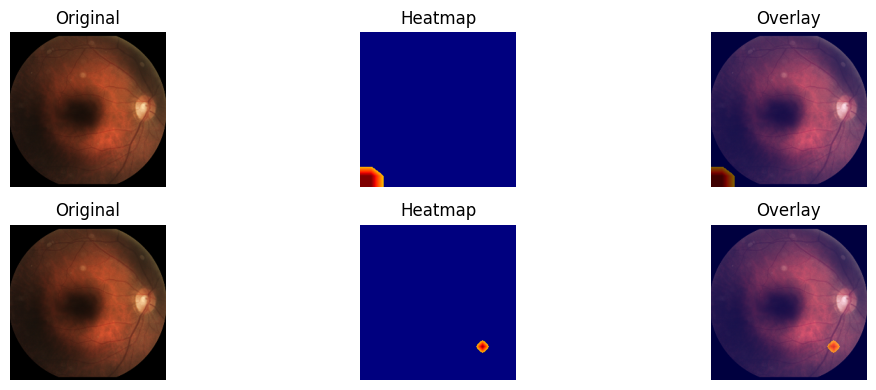

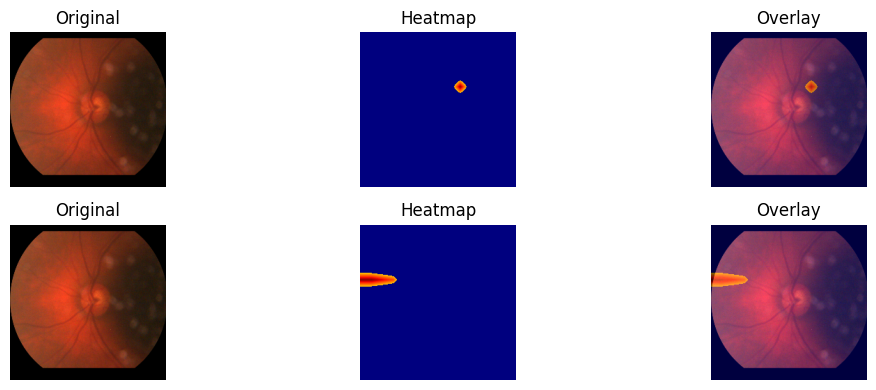

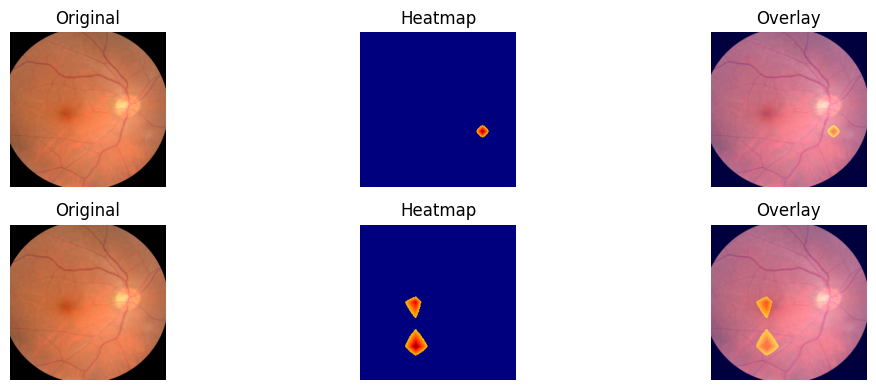

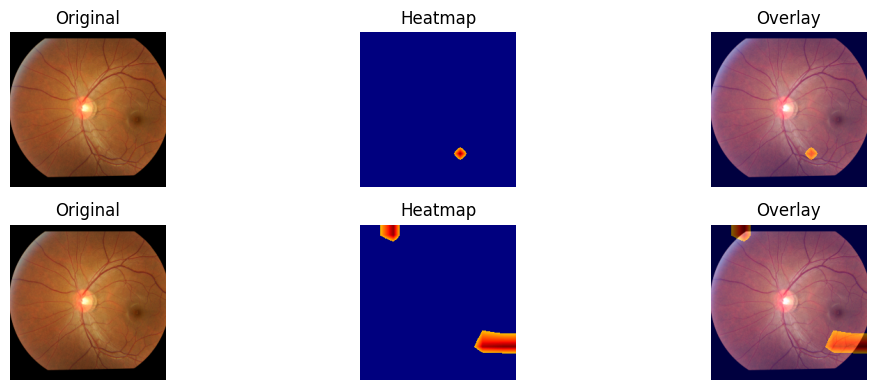

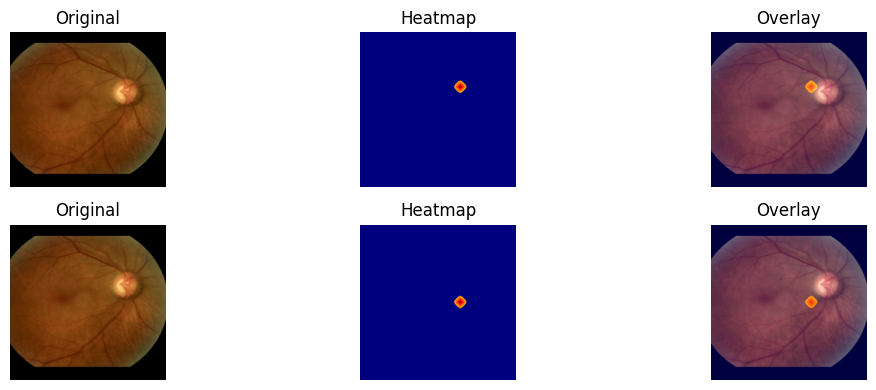

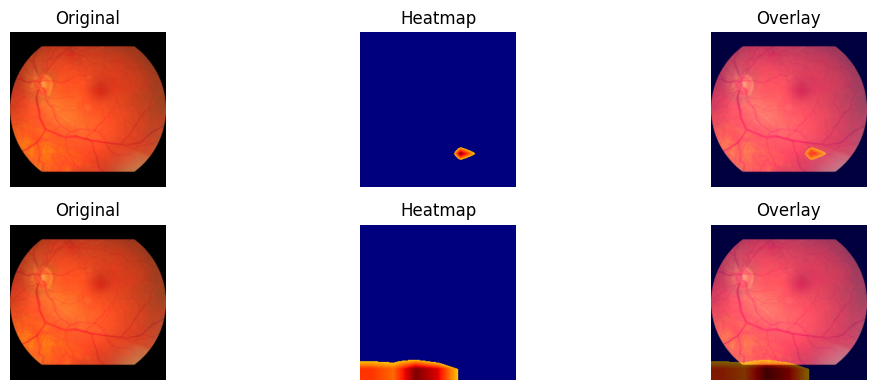

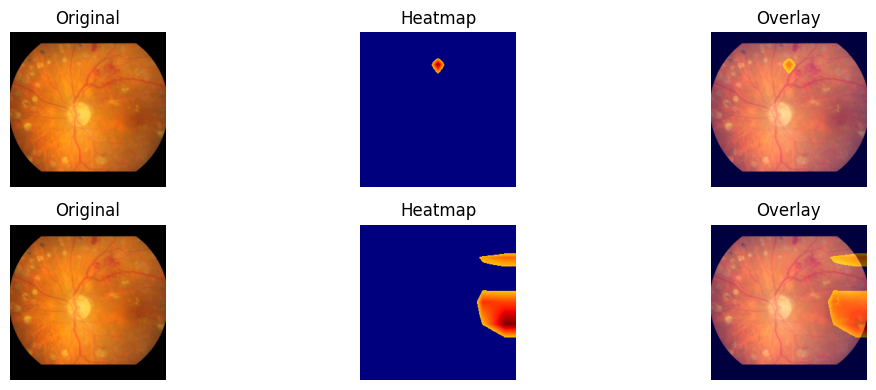

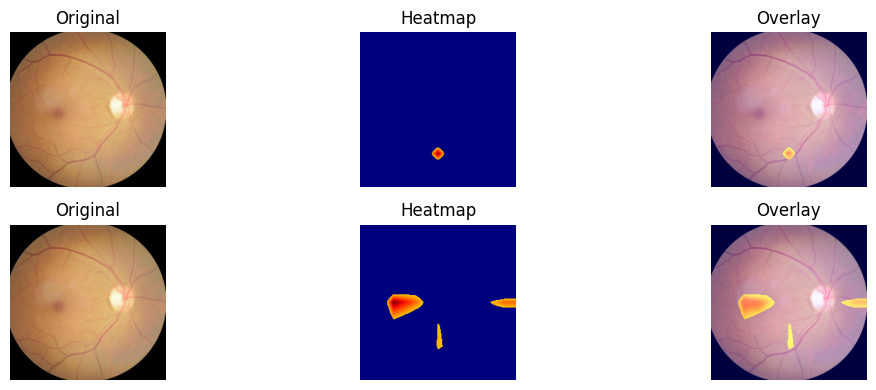

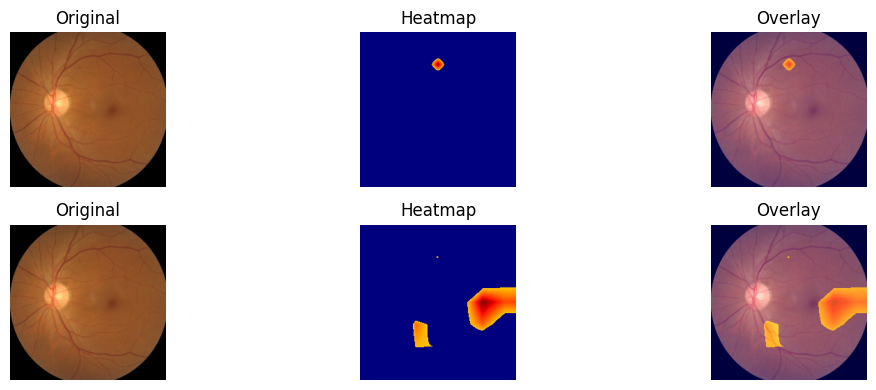

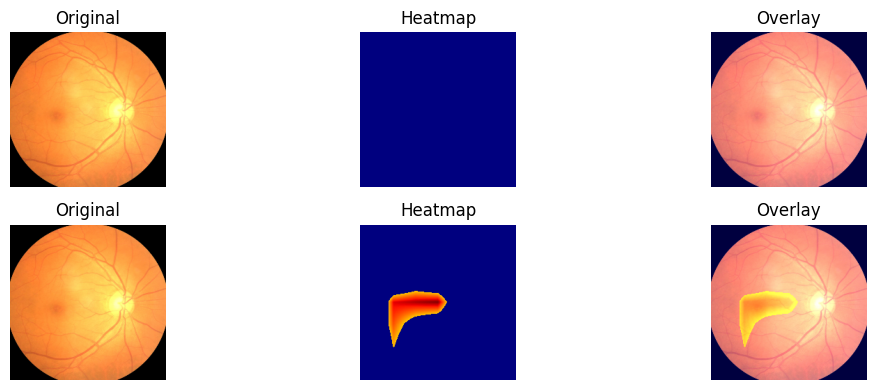

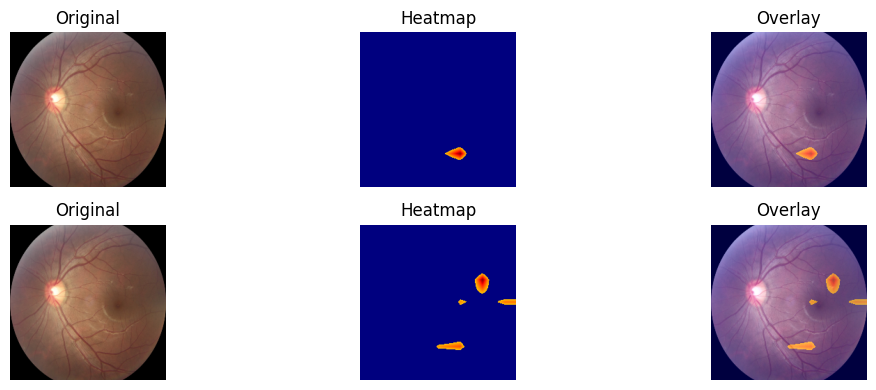

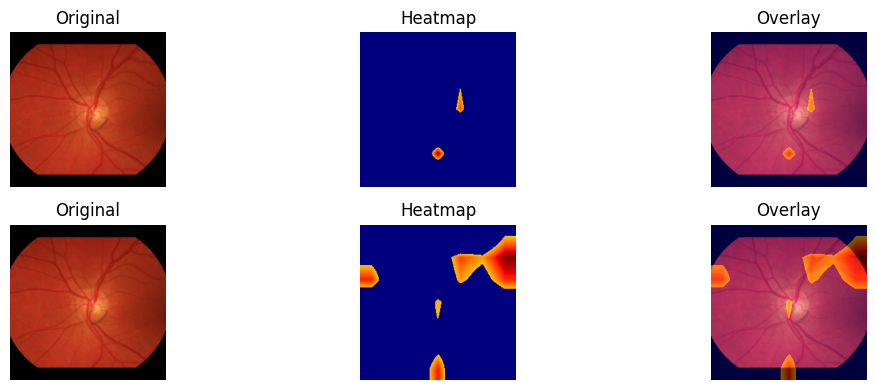

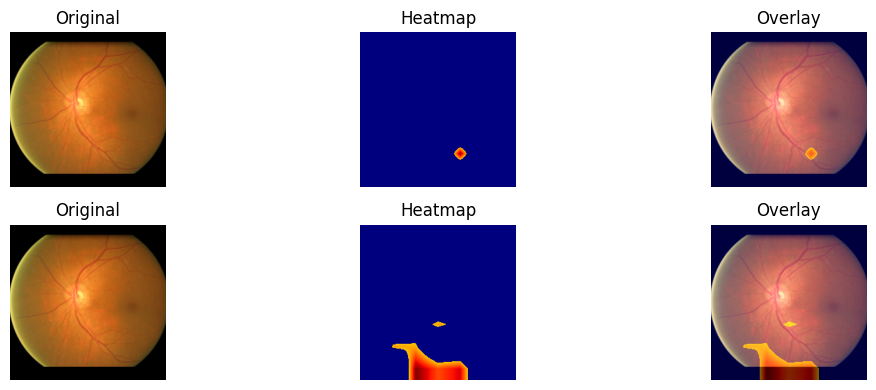

IndexError: index 16 is out of bounds for dimension 0 with size 16

In [7]:

for x in range(32):
    img = i[x]
    img = img.float()

    input_tensor = img.unsqueeze(0).cuda()

    model_lst, passed_models = load_models(modelList=["resnet152"], pretrained=True, EXPERIMENT_NAME=PREDICT_EXPERIMENT_NAME)
    model_name, model1 = list(model_lst)[0]
    gradCam_extractor = GradCAM(model1.model, target_layer="layer4")
    output = model1(input_tensor)
    cam_grad = gradCam_extractor(output.argmax().item(), output)

    model_lst, passed_models = load_models(modelList=["resnet152"], pretrained=True, EXPERIMENT_NAME=PREDICT_EXPERIMENT_NAME)
    model_name, model2 = list(model_lst)[0]
    cam_extractor = ScoreCAM(model2.model, target_layer="layer4")
    output = model2(input_tensor)
    cam = cam_extractor(output.argmax().item(), output)

    # ✅ Convert image (correct way)
    img_np = input_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

    # Optional: unnormalize if you used Normalize
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    img_np_grad = img_np.copy()

    # CAM
    cam_np = cam[0].squeeze(0).cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

    # CAM GRAD
    cam_grad_np = cam_grad[0].squeeze(0).cpu().numpy()
    cam_grad_np = (cam_grad_np - cam_grad_np.min()) / (cam_grad_np.max() - cam_grad_np.min() + 1e-8)

    # Resize CAM → match image
    cam_np = cv2.resize(cam_np, (img_np.shape[1], img_np.shape[0]))
    cam_np[cam_np<0.7] = 0


    # Resize CAM → match image
    cam_grad_np = cv2.resize(cam_grad_np, (img_np_grad.shape[1], img_np_grad.shape[0]))
    cam_grad_np[cam_grad_np<0.7] = 0


    # Heatmap
    heatmap = cm.jet(cam_np)[..., :3]

     # Heatmap
    heatmap_grad = cm.jet(cam_grad_np)[..., :3]

    # Overlay
    overlay = 1 * img_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Overlay
    overlay_grad = 1 * img_np_grad + 0.5 * heatmap_grad
    overlay_grad = np.clip(overlay_grad, 0, 1)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(2,3,1)
    plt.title("Original")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.title("Heatmap")
    plt.imshow(heatmap)
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.title("Overlay")
    plt.imshow(overlay)
    plt.axis("off")
################################
    plt.subplot(2,3,4)
    plt.title("Original")
    plt.imshow(img_np_grad)
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.title("Heatmap")
    plt.imshow(heatmap_grad)
    plt.axis("off")

    plt.subplot(2,3,6)
    plt.title("Overlay")
    plt.imshow(overlay_grad)
    plt.axis("off")
#################################
    # plt.subplot(3,3,7)
    # plt.title("Original")
    # plt.imshow(img_np)
    # plt.axis("off")

    # plt.subplot(3,3,8)
    # plt.title("Heatmap")
    # plt.imshow(heatmap)
    # plt.axis("off")

    # plt.subplot(3,3,9)
    # plt.title("Overlay")
    # plt.imshow(overlay)
    # plt.axis("off")

    plt.tight_layout()
    plt.show()

In [10]:
threshold = cam_np > 0.7

# Compute center of mass
coords = np.argwhere(threshold)
center_y, center_x = coords.mean(axis=0)

print("CAM center:", (center_x, center_y))

CAM center: (np.float64(174.3526058631922), np.float64(119.17752442996742))


In [102]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    confusion_matrix
)

def bootstrap_cls(prob_list, label_list, threshold=0.5, times=100, random_state=None):
    rng = np.random.default_rng(random_state)
    
    prob_list = np.asarray(prob_list)
    label_list = np.asarray(label_list)
    n = len(label_list)
    
    # Store metrics across bootstrap samples
    aucs, prcs = [], []
    accs, sens, spes = [], [], []
    ppvs, npvs = [], []
    
    for _ in range(times):
        # Sample with replacement
        indices = rng.integers(0, n, n)
        probs_sample = prob_list[indices]
        labels_sample = label_list[indices]
        
        # Convert probabilities to predicted labels
        preds = (probs_sample >= threshold).astype(int)
        
        # --- Metrics ---
        # AUC (handle edge case: only one class present)
        try:
            auc = roc_auc_score(labels_sample, probs_sample)
        except ValueError:
            auc = np.nan
        
        # PRC AUC
        try:
            prc = average_precision_score(labels_sample, probs_sample)
        except ValueError:
            prc = np.nan
        
        # Accuracy
        acc = accuracy_score(labels_sample, preds)
        
        # Confusion matrix: tn, fp, fn, tp
        tn, fp, fn, tp = confusion_matrix(labels_sample, preds, labels=[0, 1]).ravel()
        
        # Sensitivity (Recall)
        sen = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        
        # Specificity
        spe = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        
        # PPV (Precision)
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        
        # NPV
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan
        
        # Collect
        aucs.append(auc)
        prcs.append(prc)
        accs.append(acc)
        sens.append(sen)
        spes.append(spe)
        ppvs.append(ppv)
        npvs.append(npv)
    
    # Convert to arrays and compute std (ignore NaNs)
    def safe_std(x):
        return np.nanstd(x, ddof=1)
    
    return (
        safe_std(aucs),
        safe_std(prcs),
        safe_std(accs),
        safe_std(sens),
        safe_std(spes),
        safe_std(ppvs),
        safe_std(npvs),
    )